# 13 — DeepConf closed out, and the label-efficiency curve

**Status: current.** Covers the two studies that landed after notebook 12: the
DeepConf baseline (2026-08-05 → 08-06) and the label-efficiency sweep
(2026-08-07). Everything here reads finished artifacts — no fitting, no data
loading, CPU, seconds.

| input | study |
|:---|:---|
| `results/deepconf_asymmetry/deepconf_asymmetry_results.json` | DeepConf as a prompt-level abstention feature, DeepSeek-Qwen vs Llama |
| `results/deepconf_weighted_vote/deepconf_weighted_vote_results.json` | DeepConf used *inside* the prompt: confidence-weighted and confidence-filtered voting |
| `results/label_efficiency/label_efficiency_results.json` | `rmd_tail_q20` vs `probe_hidden_tail_q20` at 25/50/100/200/400 labelled prompts, 3 models |

**Why these two belong in one notebook.** DeepConf was the one published
baseline that could have made `rmd_tail_q20` redundant. It does not — it sits on
the chance line on both models in all three framings. That removes a threat, and
with it the last external baseline to beat. What remains is a comparison against
a *supervised probe on the same hidden states*, which wins at the full label
budget. So the only deployment claim geometry can still carry is that it needs
fewer labels. The second half of this notebook measures that claim, and finds it
real, smaller than advertised, and caused by something other than what we said.

Full write-ups with the uncertainty and the scope caveats live in
[`EXPERIMENT_LOG.md`](../EXPERIMENT_LOG.md) under **2026-08-06** (three DeepConf
entries) and **2026-08-07** (label efficiency).

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Same root-walk `_viz_utils.repo_root` uses, so this runs from the repo root or
# from notebooks/ without changes.
REPO = next(p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / ".git").exists())

if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

# The pooled sign test is not recomputed here: it is the tested helper the report
# itself calls, imported so this notebook cannot drift from the artifact.
import label_efficiency as le

RESULTS = REPO / "results"

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
})


def load(*parts: str) -> dict:
    return json.loads((RESULTS.joinpath(*parts)).read_text(encoding="utf-8"))


asym = load("deepconf_asymmetry", "deepconf_asymmetry_results.json")
vote = load("deepconf_weighted_vote", "deepconf_weighted_vote_results.json")
lab = load("label_efficiency", "label_efficiency_results.json")

print("deepconf asymmetry :", [m["label"] for m in asym["models"]], "|", asym["population"])
print("weighted vote      :", [m["label"] for m in vote["models"]], "|", vote["population"])
print("label efficiency   :", [m["label"] for m in lab["models"]],
      "| budgets", lab["budgets"], "|", lab["replicates"], "label draws each")

deepconf asymmetry : ['deepseek_qwen', 'llama'] | cap_free_valid_plurality
weighted vote      : ['DeepSeek-Qwen', 'Llama'] | cap_free_valid_plurality
label efficiency   : ['qwen', 'deepseek_qwen', 'deepseek_llama'] | budgets [25, 50, 100, 200, 400] | 10 label draws each


## 1. DeepConf is at chance — and the apparent asymmetry was a base rate

DeepConf ranks a prompt by the confidence of its sampled traces (globally, over
the tail, over the worst group). It is the closest published competitor to
`rmd_tail_q20`, and it is free: it needs no hidden states and no labels.

The first read of this comparison looked like an architecture effect —
DeepSeek-Qwen scored 0.80 AUACC where Llama scored 0.62, so DeepConf "worked
somewhat" on one model and collapsed on the other. It is not an architecture
effect. **AUACC inherits the base rate**: DeepSeek-Qwen answers 79.6% of these
prompts correctly and Llama 67.4%, so a scorer that ranks at random already
scores near those numbers. The comparison has to be made in AUROC, which is
base-rate free, or in AUACC *excess* over the base rate.

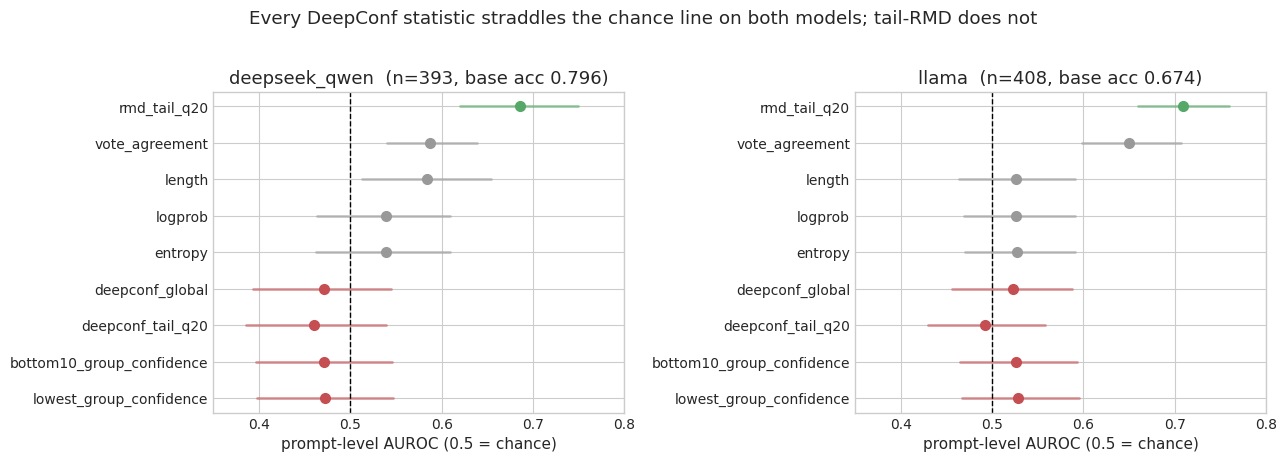

In [2]:
# Raw prompt-level AUROC for every feature in the comparison, with its bootstrap
# CI. 0.5 is chance and the only reference line that matters.
FEATURES = [
    "rmd_tail_q20", "vote_agreement", "length", "logprob", "entropy",
    "deepconf_global", "deepconf_tail_q20",
    "bottom10_group_confidence", "lowest_group_confidence",
]
FAMILY = {
    f: "deepconf" if f.startswith(("deepconf", "bottom10", "lowest"))
    else "geometry" if f.startswith("rmd")
    else "free"
    for f in FEATURES
}
FCOLOR = {"geometry": "#55A868", "free": "#999999", "deepconf": "#C44E52"}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True)
for ax, model in zip(axes, asym["models"]):
    raw = model["raw_features"]
    ys = np.arange(len(FEATURES))[::-1]
    for y, feature in zip(ys, FEATURES):
        block = raw[feature]
        low, high = block["auroc_ci"]
        colour = FCOLOR[FAMILY[feature]]
        ax.plot([low, high], [y, y], color=colour, lw=2, alpha=0.55)
        ax.plot(block["auroc"], y, "o", color=colour, ms=7)
    ax.axvline(0.5, color="black", lw=1, ls="--")
    ax.set_yticks(ys)
    ax.set_yticklabels(FEATURES)
    ax.set_xlim(0.35, 0.80)
    ax.set_xlabel("prompt-level AUROC (0.5 = chance)")
    ax.set_title(f"{model['label']}  (n={model['n_prompts']}, base acc {model['base_accuracy']:.3f})")
fig.suptitle("Every DeepConf statistic straddles the chance line on both models; tail-RMD does not", y=1.02)
fig.tight_layout()
plt.show()

**Reading it.** All four DeepConf statistics have CIs containing 0.5 on both
models — two of them sit *below* it on DeepSeek-Qwen. `rmd_tail_q20` is at 0.686
[0.620, 0.750] and 0.709 [0.660, 0.760], clear of chance on both. The free
baselines land where they always do: `vote_agreement` carries real signal
(0.587 / 0.650), `length` and `entropy` and `logprob` are weak.

The same picture in the fitted readouts. The grey bars are the level, which
is mostly the base rate; the coloured bars are what the readout actually adds.

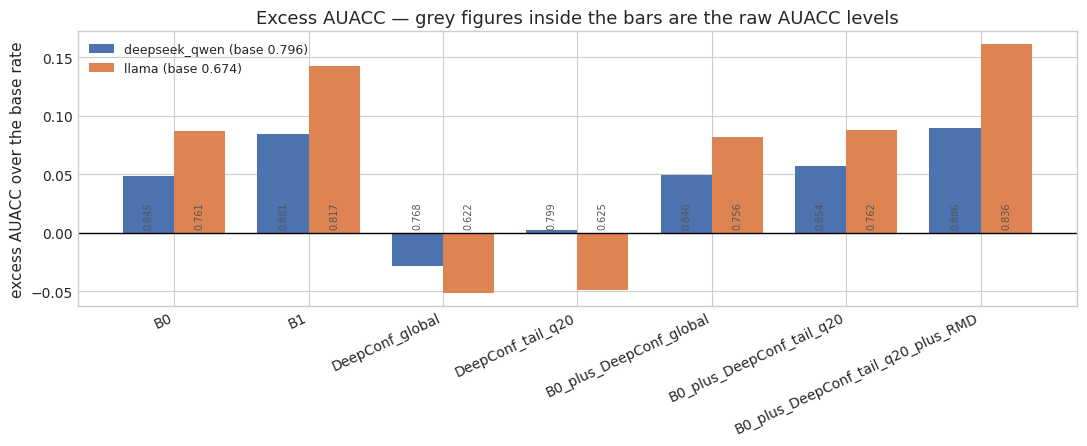

In [3]:
# Fitted logistic readouts. Plotting the excess rather than the level is the
# whole correction: the level is dominated by how often the model is right.
READOUTS = [
    "B0", "B1", "DeepConf_global", "DeepConf_tail_q20",
    "B0_plus_DeepConf_global", "B0_plus_DeepConf_tail_q20",
    "B0_plus_DeepConf_tail_q20_plus_RMD",
]
MODEL_COLOUR = {"deepseek_qwen": "#4C72B0", "llama": "#DD8452"}

fig, ax = plt.subplots(figsize=(11, 4.6))
x = np.arange(len(READOUTS))
width = 0.38
for offset, model in zip((-width / 2, width / 2), asym["models"]):
    fitted = model["fitted_readouts"]
    excess = [fitted[r]["excess_auacc"] for r in READOUTS]
    bars = ax.bar(x + offset, excess, width=width, color=MODEL_COLOUR[model["label"]],
                  label=f"{model['label']} (base {model['base_accuracy']:.3f})")
    for bar, readout in zip(bars, READOUTS):
        ax.annotate(f"{fitted[readout]['auacc']:.3f}",
                    (bar.get_x() + bar.get_width() / 2, 0.0),
                    textcoords="offset points", xytext=(0, 3), rotation=90,
                    ha="center", va="bottom", fontsize=7, color="#555555")
ax.axhline(0.0, color="black", lw=1)
ax.set_xticks(x)
ax.set_xticklabels(READOUTS, rotation=25, ha="right")
ax.set_ylabel("excess AUACC over the base rate")
ax.set_title("Excess AUACC — grey figures inside the bars are the raw AUACC levels")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

Once the base rate is out, the asymmetry inverts: Llama's excesses are *larger*
than DeepSeek-Qwen's for every readout, because Llama's lower base rate leaves
more headroom. DeepConf alone is negative or zero on both. Added to `B0` it moves
the excess by +0.001 to +0.009 — nothing. Added on top of `B0 + DeepConf`,
`rmd_tail_q20` moves it by +0.032 / +0.074.

**Ruled out:** "DeepConf works on DeepSeek-Qwen but not Llama." There is nothing
to be asymmetric about; it is at chance on both.

### 1b. Used inside the prompt, not across prompts

The second framing gives DeepConf its home-field advantage: use the confidence
to *pick* the answer, either by weighting the vote or by keeping only the top-k
most confident of the 8 siblings, then score the resulting agreement.

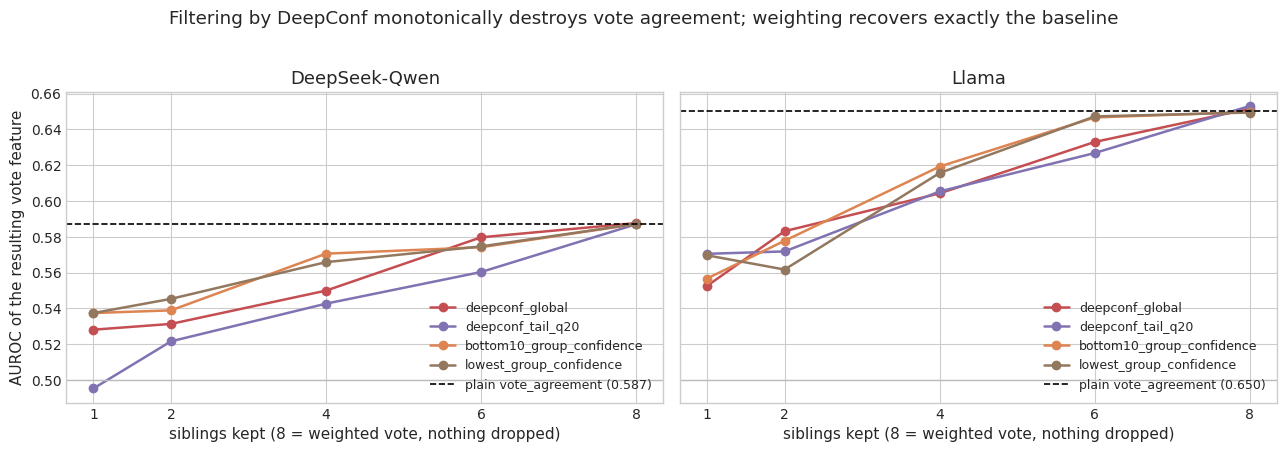

In [4]:
# Filter strength on the x axis. keep=8 is the weighted vote (nothing dropped);
# keep=1 is "trust the single most confident trace". The dashed line is plain
# vote agreement, which is what all of this is trying to improve on.
STATISTICS = ["deepconf_global", "deepconf_tail_q20",
              "bottom10_group_confidence", "lowest_group_confidence"]
KEEPS = [1, 2, 4, 6, 8]
SCOLOUR = dict(zip(STATISTICS, ["#C44E52", "#8172B2", "#DD8452", "#937860"]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), sharey=True)
for ax, model in zip(axes, vote["models"]):
    features = model["populations"][vote["population"]]["raw_vote_features"]
    for statistic in STATISTICS:
        aurocs = [
            features[f"dcvote_{statistic}" if keep == 8 else f"dcfilter{keep}_{statistic}"]["auroc"]
            for keep in KEEPS
        ]
        ax.plot(KEEPS, aurocs, "o-", color=SCOLOUR[statistic], label=statistic, lw=1.8)
    ax.axhline(features["vote_agreement"]["auroc"], color="black", ls="--", lw=1.2,
               label=f"plain vote_agreement ({features['vote_agreement']['auroc']:.3f})")
    ax.axhline(0.5, color="#BBBBBB", lw=1)
    ax.set_xticks(KEEPS)
    ax.set_xlabel("siblings kept (8 = weighted vote, nothing dropped)")
    ax.set_title(model["label"])
    ax.legend(loc="lower right")
axes[0].set_ylabel("AUROC of the resulting vote feature")
fig.suptitle("Filtering by DeepConf monotonically destroys vote agreement; weighting recovers exactly the baseline", y=1.02)
fig.tight_layout()
plt.show()

Every curve climbs back to the dashed line as the filter is relaxed and lands on
it at keep=8. That is the result stated as a picture: **weighting changes
nothing** (the weighted feature is the plain one to three decimals) and
**filtering strictly hurts**, the more aggressively the worse. There is no
operating point where a DeepConf-selected subset votes better than all eight.

That closes the baseline. Three framings, two models, all null.

## 2. Label efficiency — the last standing deployment claim

With no external baseline left, the comparison that decides whether one-class
geometry is worth anything is against a **supervised probe on the same hidden
states**: `probe_hidden_tail_q20`, an LDA fitted on both classes over the same
PCA-projected tail means that `rmd_tail_q20` fits a single Gaussian to. At the
full label budget the probe is ahead. The claim under test is therefore narrow
and specific: *the one-class score gets there on fewer labels.*

**Design.** At each budget the PCA basis, the correct-trace Gaussian, the
background Gaussian, the LDA and the logistic readout are all refitted from that
budget's prompts alone. Training sets are nested along one permutation per
replicate; the evaluation set is the `cap_free_valid_plurality` complement of the
*largest* budget and is held fixed across budgets, so every point on a curve is
scored on the same prompts. Ten label draws per model per budget, three inner
folds cross-fitting the training-side geometry so in-sample scoring cannot
flatter the discriminative side.

**Metric.** AURC, lower better. It inherits the base rate, so levels are only
comparable within a model — which is why every claim below is a *paired*
difference inside a replicate.

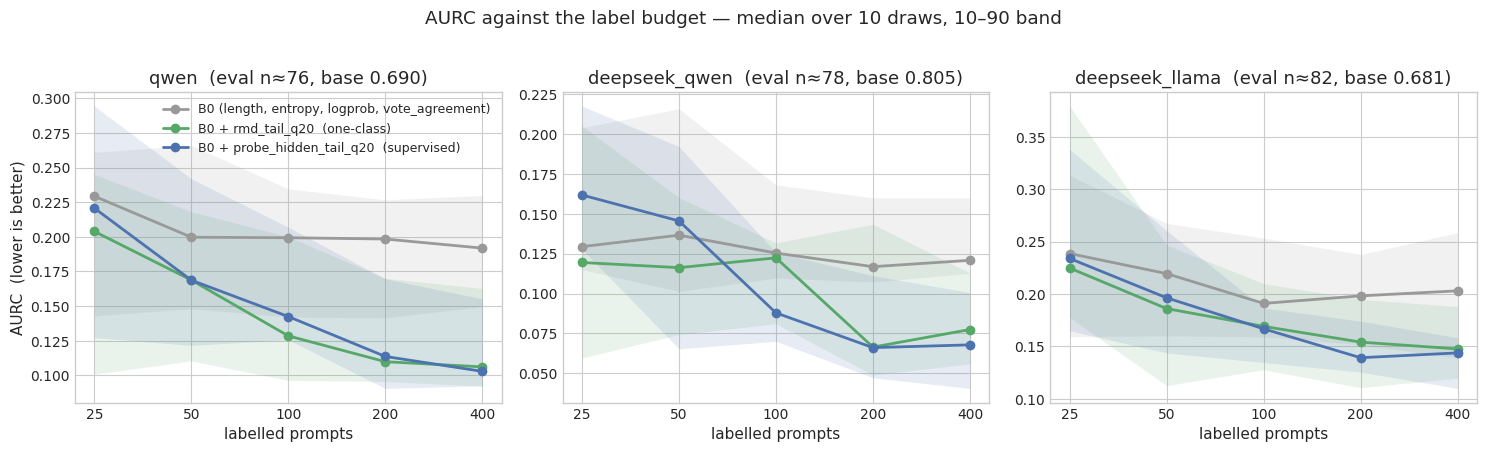

In [5]:
COLOURS = {"B0": "#999999", "B0_rmd": "#55A868", "B0_probe": "#4C72B0"}
NAMES = {
    "B0": "B0 (length, entropy, logprob, vote_agreement)",
    "B0_rmd": "B0 + rmd_tail_q20  (one-class)",
    "B0_probe": "B0 + probe_hidden_tail_q20  (supervised)",
}
BUDGETS = lab["budgets"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
for ax, model in zip(axes, lab["models"]):
    curves = {int(c["budget"]): c for c in model["curves"]}
    budgets = sorted(curves)
    for key in ("B0", "B0_rmd", "B0_probe"):
        median = [curves[b]["aurc"][key]["median"] for b in budgets]
        low = [curves[b]["aurc"][key]["p10"] for b in budgets]
        high = [curves[b]["aurc"][key]["p90"] for b in budgets]
        ax.plot(budgets, median, "o-", color=COLOURS[key], label=NAMES[key], lw=2)
        ax.fill_between(budgets, low, high, color=COLOURS[key], alpha=0.13, lw=0)
    first = curves[budgets[0]]
    ax.set_xscale("log")
    ax.set_xticks(budgets)
    ax.set_xticklabels([str(b) for b in budgets])
    ax.set_xlabel("labelled prompts")
    ax.set_title(f"{model['label']}  (eval n≈{first['n_eval']['median']:.0f}, "
                 f"base {first['eval_base_accuracy']['median']:.3f})")
axes[0].set_ylabel("AURC  (lower is better)")
axes[0].legend(loc="upper right")
fig.suptitle("AURC against the label budget — median over 10 draws, 10–90 band", y=1.02)
fig.tight_layout()
plt.show()

Both features improve with labels and both beat `B0` everywhere; the bands
overlap heavily because the evaluation set is small by construction (the largest
budget consumes most of the prompts). The bands are *not* the statistic — the
comparison is paired, so the difference inside a replicate is far tighter than
the two marginals suggest.

### The crossing

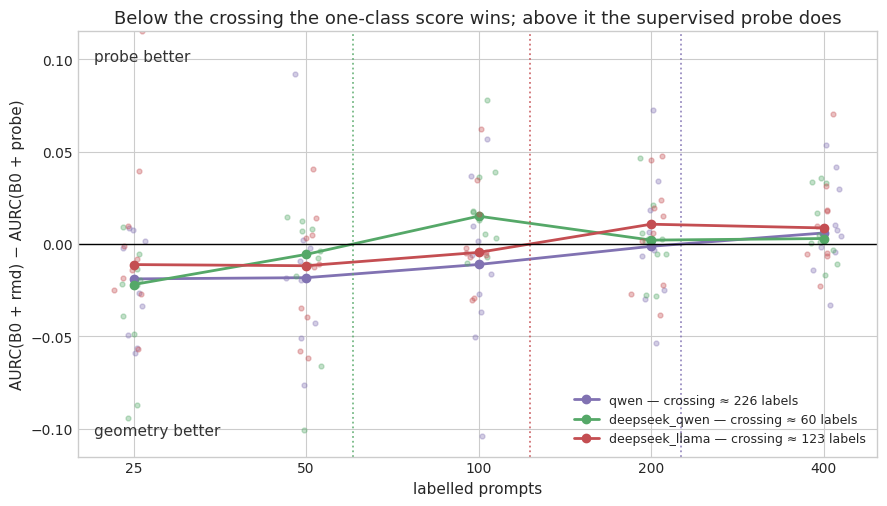

1 draw(s) fall outside the plotted range and are drawn at the edge.


In [6]:
# The paired difference, which is the actual estimator. Faint points are the
# individual label draws; the line is their median. Jitter is horizontal only.
KEY = "delta_aurc_B0_rmd_minus_B0_probe"
LINE_COLOUR = {"qwen": "#8172B2", "deepseek_qwen": "#55A868", "deepseek_llama": "#C44E52"}
YLIM = (-0.115, 0.115)

rng = np.random.default_rng(0)
clipped = 0
fig, ax = plt.subplots(figsize=(9, 5.2))
for model in lab["models"]:
    colour = LINE_COLOUR[model["label"]]
    xs, medians = [], []
    for budget in BUDGETS:
        values = [row[KEY] for row in model["replicate_rows"] if int(row["budget"]) == budget]
        if not values:
            continue
        xs.append(budget)
        medians.append(float(np.median(values)))
        jitter = budget * np.exp(rng.normal(0.0, 0.035, len(values)))
        ax.plot(jitter, np.clip(values, *YLIM), ".", color=colour, alpha=0.35, ms=7)
        clipped += int(np.sum((np.array(values) < YLIM[0]) | (np.array(values) > YLIM[1])))
    crossing = model["crossing"]
    ax.plot(xs, medians, "o-", color=colour, lw=2,
            label=f"{model['label']} — crossing ≈ {crossing['budget']:.0f} labels")
    ax.axvline(crossing["budget"], color=colour, ls=":", lw=1.3, alpha=0.8)

ax.axhline(0.0, color="black", lw=1)
ax.set_xscale("log")
ax.set_xticks(BUDGETS)
ax.set_xticklabels([str(b) for b in BUDGETS])
ax.set_ylim(*YLIM)
ax.set_xlabel("labelled prompts")
ax.set_ylabel("AURC(B0 + rmd) − AURC(B0 + probe)")
ax.set_title("Below the crossing the one-class score wins; above it the supervised probe does")
ax.annotate("geometry better", (0.02, 0.05), xycoords="axes fraction", color="#333333")
ax.annotate("probe better", (0.02, 0.93), xycoords="axes fraction", color="#333333")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()
print(f"{clipped} draw(s) fall outside the plotted range and are drawn at the edge.")

A crossing exists, in the same direction, in all three models — at **60**
(DeepSeek-Qwen), **123** (Llama) and **226** (Qwen) labelled prompts. Nothing
about the vertical scale is impressive: the medians live inside ±0.02 AURC, which
no single model's ~80-prompt evaluation set can resolve on its own. What carries
the claim is that three independent datasets agree on the sign at both ends —
3/3 on the geometry side at 25 and 50 labels, 0/3 at 200 and 400.

### The mechanism is not the one we claimed

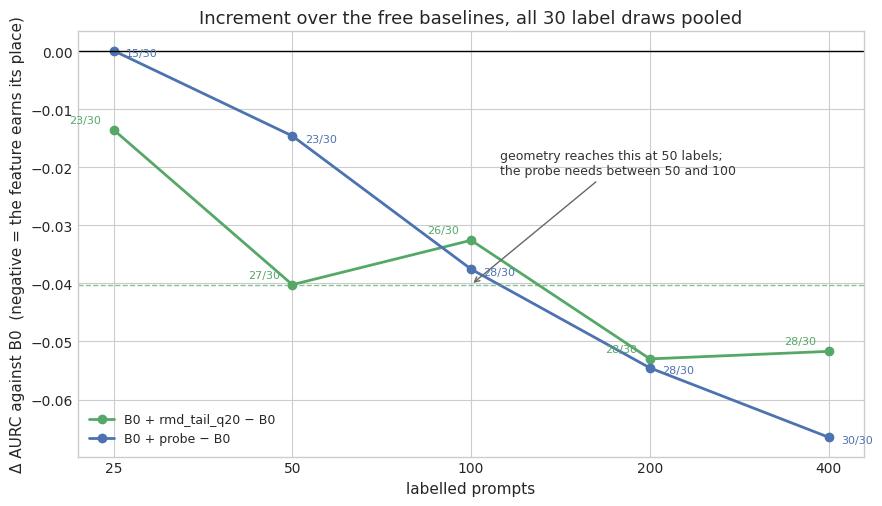

In [7]:
# Increment over B0 for each feature separately, pooled across all three models
# (30 label draws per budget). Annotations are the number of draws on the
# helping side.
table = le.pooled_sign_table(lab["models"], BUDGETS)
# The two series nearly coincide at 100-200 labels, so the win counts are offset
# horizontally rather than vertically -- that stays legible whatever the medians do.
SERIES = (
    ("delta_aurc_B0_rmd_minus_B0", "#55A868", "B0 + rmd_tail_q20 − B0", (-9, 5), "right"),
    ("delta_aurc_B0_probe_minus_B0", "#4C72B0", "B0 + probe − B0", (9, -4), "left"),
)

fig, ax = plt.subplots(figsize=(9, 5.2))
for key, colour, name, offset, alignment in SERIES:
    medians = [row["quantities"][key]["median"] for row in table]
    pooled = [row["quantities"][key]["pooled"] for row in table]
    ax.plot(BUDGETS, medians, "o-", color=colour, lw=2, label=name)
    for budget, median, summary in zip(BUDGETS, medians, pooled):
        wins = int(round(summary["win_rate"] * summary["n_replicates"]))
        ax.annotate(f"{wins}/{summary['n_replicates']}", (budget, median),
                    textcoords="offset points", xytext=offset, ha=alignment,
                    fontsize=8, color=colour)

geometry_at_50 = table[1]["quantities"]["delta_aurc_B0_rmd_minus_B0"]["median"]
ax.axhline(0.0, color="black", lw=1)
ax.axhline(geometry_at_50, color="#55A868", ls="--", lw=1, alpha=0.7)
ax.annotate("geometry reaches this at 50 labels;\nthe probe needs between 50 and 100",
            xy=(100, geometry_at_50), xytext=(112, geometry_at_50 + 0.019), fontsize=9,
            color="#333333", arrowprops=dict(arrowstyle="->", color="#666666", lw=1))
ax.set_xscale("log")
ax.set_xticks(BUDGETS)
ax.set_xticklabels([str(b) for b in BUDGETS])
ax.set_xlabel("labelled prompts")
ax.set_ylabel("Δ AURC against B0  (negative = the feature earns its place)")
ax.set_title("Increment over the free baselines, all 30 label draws pooled")
ax.legend(loc="lower left")
fig.tight_layout()
plt.show()

This is the figure that corrects the story. At 25 labels the supervised probe
adds **exactly nothing** over `B0` — median 0.000, 15/30 draws, a coin flip —
while geometry adds −0.014 on 23/30. The small-budget lead is **the LDA
collapsing, not the Gaussian excelling**. Say it the other way and the claim is
wrong.

The size of what survives: geometry's increment reaches −0.040 at 50 labels; the
probe crosses that level somewhere between 50 (−0.015) and 100 (−0.038). That is
roughly a **2× label saving, confined to the 25–100 band** — not a general
advantage.

In [8]:
# The pooled sign table exactly as the report prints it. `agree` counts models
# whose own median lands on the geometry side; it is the statistic that does not
# assume independence, because draws inside one model share an evaluation set.
COLUMNS = [
    ("delta_aurc_B0_rmd_minus_B0", "B0+rmd − B0"),
    ("delta_aurc_B0_probe_minus_B0", "B0+probe − B0"),
    ("delta_aurc_B0_rmd_minus_B0_probe", "B0+rmd − B0+probe"),
    ("delta_aurc_B0_both_minus_B0_rmd", "B0+both − B0+rmd"),
    ("auroc_rmd_minus_probe", "AUROC rmd − probe"),
]

header = f"{'labels':>6} " + " ".join(f"{name:>26}" for _, name in COLUMNS) + f" {'agree':>6}"
print(header)
print("-" * len(header))
for row in table:
    cells = []
    for key, _ in COLUMNS:
        entry = row["quantities"][key]
        pooled = entry["pooled"]
        wins = int(round(pooled["win_rate"] * pooled["n_replicates"]))
        cells.append(f"{entry['median']:+.3f} {wins:>2}/{pooled['n_replicates']} p={pooled['p_sign']:.3f}")
    agreement = row["quantities"]["delta_aurc_B0_rmd_minus_B0_probe"]
    agree = f"{agreement['models_agreeing']}/{agreement['n_models']}"
    print(f"{row['budget']:>6} " + " ".join(f"{c:>26}" for c in cells) + f" {agree:>6}")
print()
print("negative favours the left readout, except the last column where positive favours geometry;")
print("pooled p summarises consistency across 30 draws and is not a test on independent observations.")

labels                B0+rmd − B0              B0+probe − B0          B0+rmd − B0+probe           B0+both − B0+rmd          AUROC rmd − probe  agree
----------------------------------------------------------------------------------------------------------------------------------------------------
    25       -0.014 23/30 p=0.005       +0.000 15/30 p=1.000       -0.019 23/30 p=0.005       +0.000 13/30 p=0.585       +0.023 17/30 p=0.585    3/3
    50       -0.040 27/30 p=0.000       -0.015 23/30 p=0.005       -0.011 20/30 p=0.099       -0.001 16/30 p=0.856       -0.013 13/30 p=0.585    3/3
   100       -0.033 26/30 p=0.000       -0.038 28/30 p=0.000       -0.000 15/30 p=1.000       -0.005 19/30 p=0.200       +0.012 16/30 p=0.856    2/3
   200       -0.053 28/30 p=0.000       -0.055 28/30 p=0.000       +0.002 12/30 p=0.362       -0.006 21/30 p=0.043       -0.048  9/30 p=0.043    0/3
   400       -0.052 28/30 p=0.000       -0.067 30/30 p=0.000       +0.006 11/30 p=0.200       -0.007 24/30

## 3. What this leaves standing

**Ruled in.**
- DeepConf is at chance as a prompt-level abstention feature on both models, and
  cannot improve a vote when used inside a prompt. It is not a competitor.
- A label-efficiency crossing exists in the same direction in all three models,
  bracketed at 60–226 labelled prompts, with unanimous model agreement at both
  ends of the sweep.
- Geometry's increment over the free baselines is significant at 25 labels
  (23/30); the probe's is not (15/30).

**Ruled out.**
- *The claimed mechanism.* The small-budget lead comes from the supervised probe
  failing, not from one-class geometry being unusually sample-efficient.
- *Geometry at the full budget.* The earlier single-draw pilot was a draw. Over
  ten it reverses (11/30 at 400), and the probe's solo AUROC advantage there is
  2/30, p<0.001.
- *The probe being redundant with geometry.* Adding it on top costs −0.006 at 200
  (p=0.043) and −0.007 at 400 (p=0.001); it earns its place at large budgets.

**Limitations to carry forward.**
- `rmd_tail_q20` averages *per-token* distances over the tail; the probe runs an
  LDA on the tail *region mean*. They differ in supervision **and** in pooling
  order, and this study does not separate the two — so "one-class geometry needs
  fewer labels" is a slightly stronger sentence than what was measured.
- Evaluation sets are 76–82 prompts. The paired design is what makes them usable;
  no unpaired level here should be quoted.
- The label-efficiency sweep deviates from the frozen pipeline in three places
  (per-trace token subsampling, tail-only retention, pinned PCA solver). Its
  numbers are not interchangeable with the frozen artifacts.

This closes the label-efficiency question. Nothing in either study suggests a
variant worth running.